In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
# Initialize tqdm with pandas
tqdm.pandas()

In [18]:
import os
os.chdir(r'C:\Users\Admin\Documents\Digilians\Second Term\AI-202 Natural Language Processing\Sections\Lab 1\Task')

In [19]:
df=pd.read_csv('youtube.csv')
df.head()

,link,title,description,category
0,JLZlCZ0,Ep 1| Travelling through North East India | Of...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nT...,travel
1,i9E_Blai8vk,Welcome to Bali | Travel Vlog | Priscilla Lee,Priscilla Lee\n45.6K subscribers\nSUBSCRIBE\n*...,travel
2,r284c-q8oY,My Solo Trip to ALASKA | Cruising From Vancouv...,Allison Anderson\n588K subscribers\nSUBSCRIBE\...,travel
3,Qmi-Xwq-ME,Traveling to the Happiest Country in the World!!,Yes Theory\n6.65M subscribers\nSUBSCRIBE\n*BLA...,travel
4,_lcOX55Ef70,Solo in Paro Bhutan | Tiger's Nest visit | Bhu...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nH...,travel


In [20]:
df.shape

(3599, 4)

In [35]:
df['description'][100].lower()

"lost leblanc\n1.83m subscribers\nsubscribe\nwith your trip just ahead, it's time to learn how to make a travel video with any camera. these are my top 10 tips to making a cinematic and engaging travel video of your upcoming adventures.\n\nwant to join our family of photographers, videographers and storytellers?\nget started with my free 1-hour content creator training here: \nshow more"

In [36]:
df['description']=df['description'].str.lower()
df.head()

,link,title,description,category
0,JLZlCZ0,ep travelling through north east india off t...,tanya khanijow\n671k subscribers\nsubscribe\nt...,travel
1,i9E_Blai8vk,welcome to bali travel vlog priscilla lee,priscilla lee\n45.6k subscribers\nsubscribe\n*...,travel
2,r284c-q8oY,my solo trip to alaska cruising from vancouve...,allison anderson\n588k subscribers\nsubscribe\...,travel
3,Qmi-Xwq-ME,traveling to the happiest country in the world,yes theory\n6.65m subscribers\nsubscribe\n*bla...,travel
4,_lcOX55Ef70,solo in paro bhutan tigers nest visit bhutan...,tanya khanijow\n671k subscribers\nsubscribe\nh...,travel


<Axes: xlabel='category', ylabel='count'>

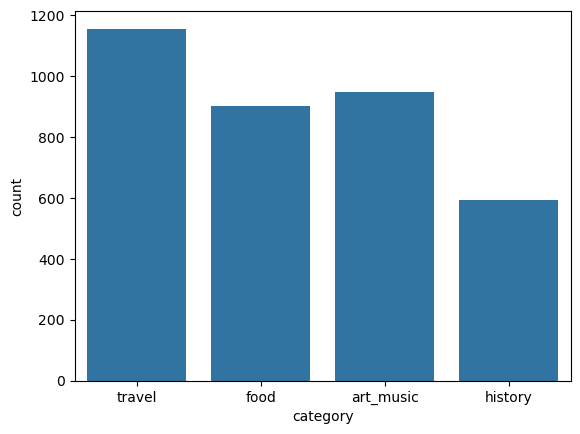

In [37]:
sns.countplot(data=df,x='category')

In [38]:
import re
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub('', text)

In [39]:
df['description']=df['description'].progress_apply(lambda x : remove_html_tags(x))
df.head()

100%|██████████████████████████████████████████████████████████████████████████| 3599/3599 [00:00<00:00, 329138.96it/s]


,link,title,description,category
0,JLZlCZ0,ep travelling through north east india off t...,tanya khanijow\n671k subscribers\nsubscribe\nt...,travel
1,i9E_Blai8vk,welcome to bali travel vlog priscilla lee,priscilla lee\n45.6k subscribers\nsubscribe\n*...,travel
2,r284c-q8oY,my solo trip to alaska cruising from vancouve...,allison anderson\n588k subscribers\nsubscribe\...,travel
3,Qmi-Xwq-ME,traveling to the happiest country in the world,yes theory\n6.65m subscribers\nsubscribe\n*bla...,travel
4,_lcOX55Ef70,solo in paro bhutan tigers nest visit bhutan...,tanya khanijow\n671k subscribers\nsubscribe\nh...,travel


In [40]:
def remove_url(text):
    pattern=re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'',text)

df['description']=df['description'].progress_apply(lambda x : remove_url(x))
df.head()

  0%|                                                                                         | 0/3599 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████| 3599/3599 [00:00<00:00, 178056.81it/s]


,link,title,description,category
0,JLZlCZ0,ep travelling through north east india off t...,tanya khanijow\n671k subscribers\nsubscribe\nt...,travel
1,i9E_Blai8vk,welcome to bali travel vlog priscilla lee,priscilla lee\n45.6k subscribers\nsubscribe\n*...,travel
2,r284c-q8oY,my solo trip to alaska cruising from vancouve...,allison anderson\n588k subscribers\nsubscribe\...,travel
3,Qmi-Xwq-ME,traveling to the happiest country in the world,yes theory\n6.65m subscribers\nsubscribe\n*bla...,travel
4,_lcOX55Ef70,solo in paro bhutan tigers nest visit bhutan...,tanya khanijow\n671k subscribers\nsubscribe\nh...,travel


In [29]:
import sys
!{sys.executable} -m pip install --user emoji

   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   ---------------------------------------- 608.4/608.4 kB 4.8 MB/s eta 0:00:00


In [41]:

import emoji

df['description'] = df['description'].progress_apply(emoji.demojize)
df.head()

100%|████████████████████████████████████████████████████████████████████████████| 3599/3599 [00:01<00:00, 2651.48it/s]


,link,title,description,category
0,JLZlCZ0,ep travelling through north east india off t...,tanya khanijow\n671k subscribers\nsubscribe\nt...,travel
1,i9E_Blai8vk,welcome to bali travel vlog priscilla lee,priscilla lee\n45.6k subscribers\nsubscribe\n*...,travel
2,r284c-q8oY,my solo trip to alaska cruising from vancouve...,allison anderson\n588k subscribers\nsubscribe\...,travel
3,Qmi-Xwq-ME,traveling to the happiest country in the world,yes theory\n6.65m subscribers\nsubscribe\n*bla...,travel
4,_lcOX55Ef70,solo in paro bhutan tigers nest visit bhutan...,tanya khanijow\n671k subscribers\nsubscribe\nh...,travel


In [42]:
def remove_digits(text):
    
    return re.sub(r'\d+', '', text)

df['description'] = df['description'].progress_apply(lambda x: remove_digits(x))
df.head()

100%|███████████████████████████████████████████████████████████████████████████| 3599/3599 [00:00<00:00, 72388.41it/s]


,link,title,description,category
0,JLZlCZ0,ep travelling through north east india off t...,tanya khanijow\nk subscribers\nsubscribe\nthe ...,travel
1,i9E_Blai8vk,welcome to bali travel vlog priscilla lee,priscilla lee\n.k subscribers\nsubscribe\n*dis...,travel
2,r284c-q8oY,my solo trip to alaska cruising from vancouve...,allison anderson\nk subscribers\nsubscribe\ni ...,travel
3,Qmi-Xwq-ME,traveling to the happiest country in the world,yes theory\n.m subscribers\nsubscribe\n*black ...,travel
4,_lcOX55Ef70,solo in paro bhutan tigers nest visit bhutan...,tanya khanijow\nk subscribers\nsubscribe\nhere...,travel


In [32]:
import string

In [33]:
exclude=string.punctuation
exclude

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [43]:
def remove_punc(text):
    for char in exclude:
        text=text.replace(char,'')
    return text

df['description']=df['description'].progress_apply(lambda x : remove_punc(x))
df.head()

100%|███████████████████████████████████████████████████████████████████████████| 3599/3599 [00:00<00:00, 55725.45it/s]


,link,title,description,category
0,JLZlCZ0,ep travelling through north east india off t...,tanya khanijow\nk subscribers\nsubscribe\nthe ...,travel
1,i9E_Blai8vk,welcome to bali travel vlog priscilla lee,priscilla lee\nk subscribers\nsubscribe\ndiscl...,travel
2,r284c-q8oY,my solo trip to alaska cruising from vancouve...,allison anderson\nk subscribers\nsubscribe\ni ...,travel
3,Qmi-Xwq-ME,traveling to the happiest country in the world,yes theory\nm subscribers\nsubscribe\nblack fr...,travel
4,_lcOX55Ef70,solo in paro bhutan tigers nest visit bhutan...,tanya khanijow\nk subscribers\nsubscribe\nhere...,travel


In [44]:
from nltk.corpus import stopwords

In [46]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [47]:
StopWords = stopwords.words("english")
StopWords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [48]:
def remove_stopwords(text):
    filtered_text = ' '.join(word for word in text.split() if word.lower() not in StopWords)
    return filtered_text

df['description']=df['description'].progress_apply(lambda x : remove_stopwords(x))
df.head()

100%|████████████████████████████████████████████████████████████████████████████| 3599/3599 [00:00<00:00, 6390.98it/s]


,link,title,description,category
0,JLZlCZ0,ep travelling through north east india off t...,tanya khanijow k subscribers subscribe journey...,travel
1,i9E_Blai8vk,welcome to bali travel vlog priscilla lee,priscilla lee k subscribers subscribe disclaim...,travel
2,r284c-q8oY,my solo trip to alaska cruising from vancouve...,allison anderson k subscribers subscribe spent...,travel
3,Qmi-Xwq-ME,traveling to the happiest country in the world,yes theory subscribers subscribe black friday ...,travel
4,_lcOX55Ef70,solo in paro bhutan tigers nest visit bhutan...,tanya khanijow k subscribers subscribe here’s ...,travel


In [49]:
df['description'][0]

'tanya khanijow k subscribers subscribe journey arunachal north east india begins train journey guwahati murkongselek head pasighat travel companions getting started exploring tiny glimpse arunachal far markets bridges adventure get better next video show'

In [50]:
df['description']

0       tanya khanijow k subscribers subscribe journey...
1       priscilla lee k subscribers subscribe disclaim...
2       allison anderson k subscribers subscribe spent...
3       yes theory subscribers subscribe black friday ...
4       tanya khanijow k subscribers subscribe here’s ...
                              ...                        
3594    crashcourse subscribers subscribe st century b...
3595    publications office european union k subscribe...
3596    history time k subscribers subscribe watch lat...
3597    mr raymonds civics social studies academy k su...
3598    paul sargent k subscribers subscribe video cov...
Name: description, Length: 3599, dtype: object

In [51]:
df.to_csv('cleaned_youtube.csv', index=False)

In [52]:
def remove_k(text):
    return re.sub(r'\bk\b', '', text)

In [53]:
def remove_strange_chars(text):
    return re.sub(r'[^\x00-\x7F]+', ' ', text)

In [54]:
def clean_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

In [55]:
df['description'] = df['description'].progress_apply(remove_k)
df['description'] = df['description'].progress_apply(remove_strange_chars)
df['description'] = df['description'].progress_apply(clean_spaces)

100%|███████████████████████████████████████████████████████████████████████████| 3599/3599 [00:00<00:00, 55286.65it/s]


In [56]:
custom_words = ['subscribe', 'subscribers', 'show']

def remove_custom_words(text):
    return ' '.join(word for word in text.split() if word not in custom_words)

df['description'] = df['description'].progress_apply(remove_custom_words)

100%|██████████████████████████████████████████████████████████████████████████| 3599/3599 [00:00<00:00, 106763.56it/s]


In [58]:
df.to_csv('cleaned_youtube.csv', index=False)